Processing dose_od_pair_9.csv  (film_type=EBTXD, channels=['multi', 'r', 'g', 'b'])
Saved → /home/michaelgajda/cal_Lab_Work/film_triple_channel_dosimetry/analyze_Dose_CSVs/hists/EBTXD_May15/dose_histogram_film_009_EBTXD_all.png


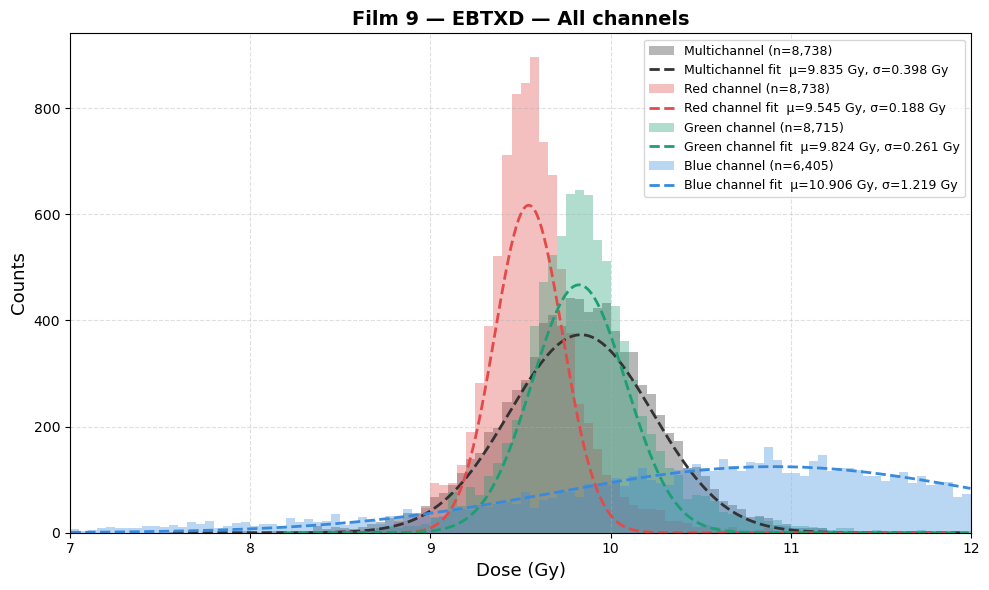

Processing dose_od_pair_32.csv  (film_type=EBTXD, channels=['multi', 'r', 'g', 'b'])
Saved → /home/michaelgajda/cal_Lab_Work/film_triple_channel_dosimetry/analyze_Dose_CSVs/hists/EBTXD_May15/dose_histogram_film_032_EBTXD_all.png


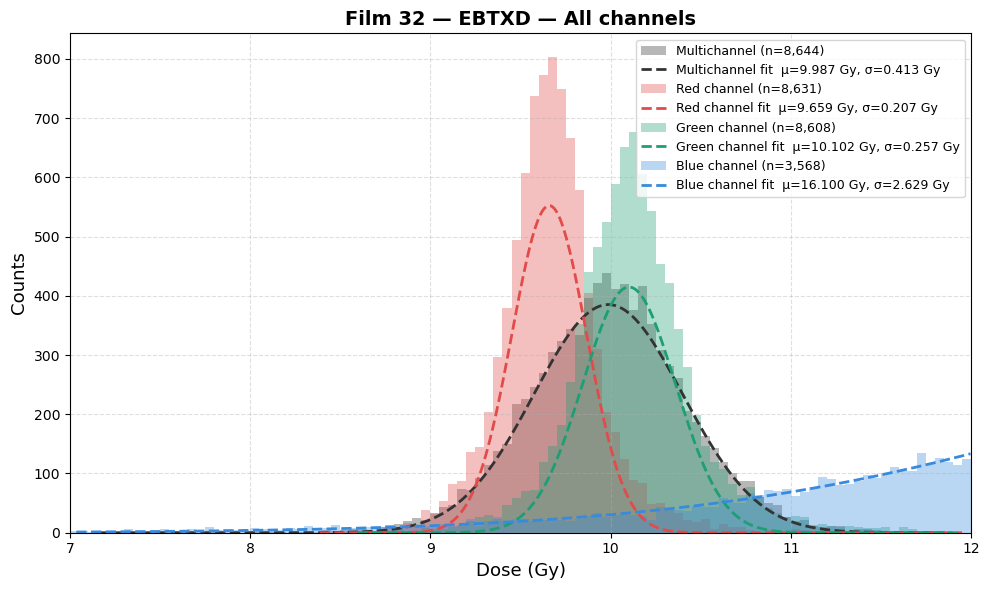

Processing dose_od_pair_33.csv  (film_type=EBTXD, channels=['multi', 'r', 'g', 'b'])


/tmp/ipykernel_1021806/2436207775.py:33: RuntimeWarning: divide by zero encountered in divide
  return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
/usr/lib/python3/dist-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Saved → /home/michaelgajda/cal_Lab_Work/film_triple_channel_dosimetry/analyze_Dose_CSVs/hists/EBTXD_May15/dose_histogram_film_033_EBTXD_all.png


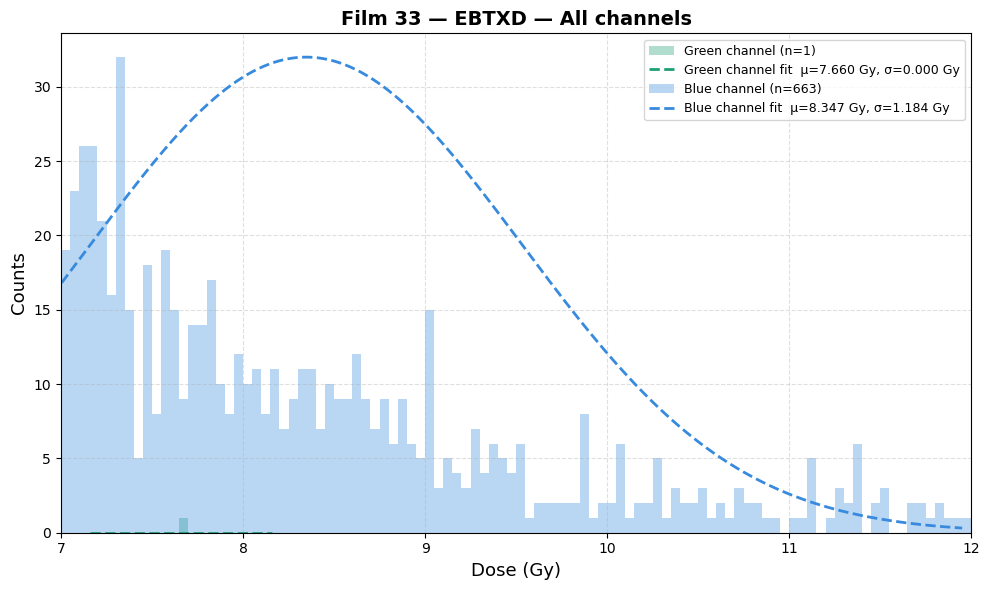

Processing dose_od_pair_34.csv  (film_type=EBTXD, channels=['multi', 'r', 'g', 'b'])
Saved → /home/michaelgajda/cal_Lab_Work/film_triple_channel_dosimetry/analyze_Dose_CSVs/hists/EBTXD_May15/dose_histogram_film_034_EBTXD_all.png


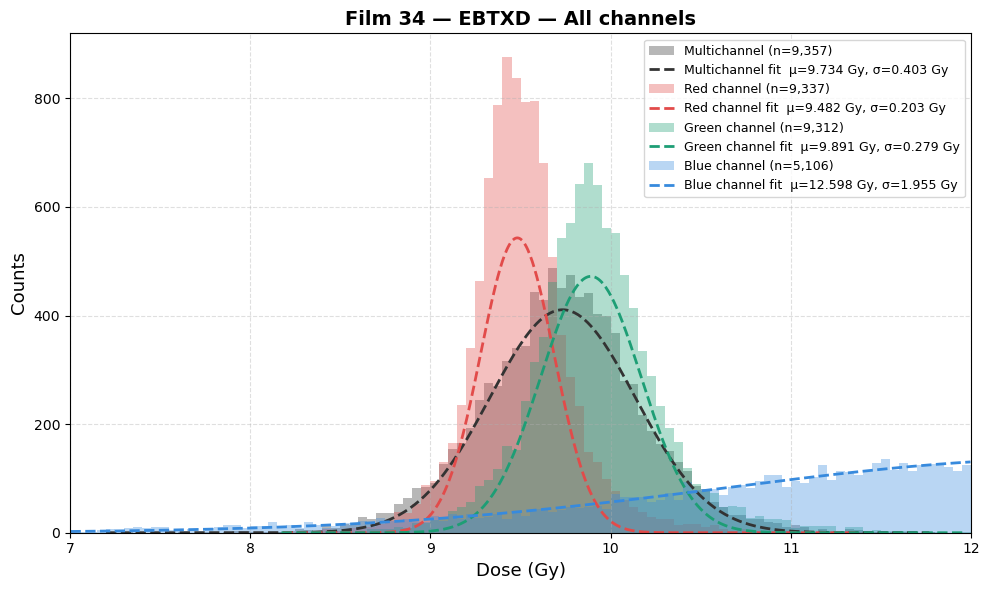

Processing dose_od_pair_42.csv  (film_type=EBTXD, channels=['multi', 'r', 'g', 'b'])
Saved → /home/michaelgajda/cal_Lab_Work/film_triple_channel_dosimetry/analyze_Dose_CSVs/hists/EBTXD_May15/dose_histogram_film_042_EBTXD_all.png


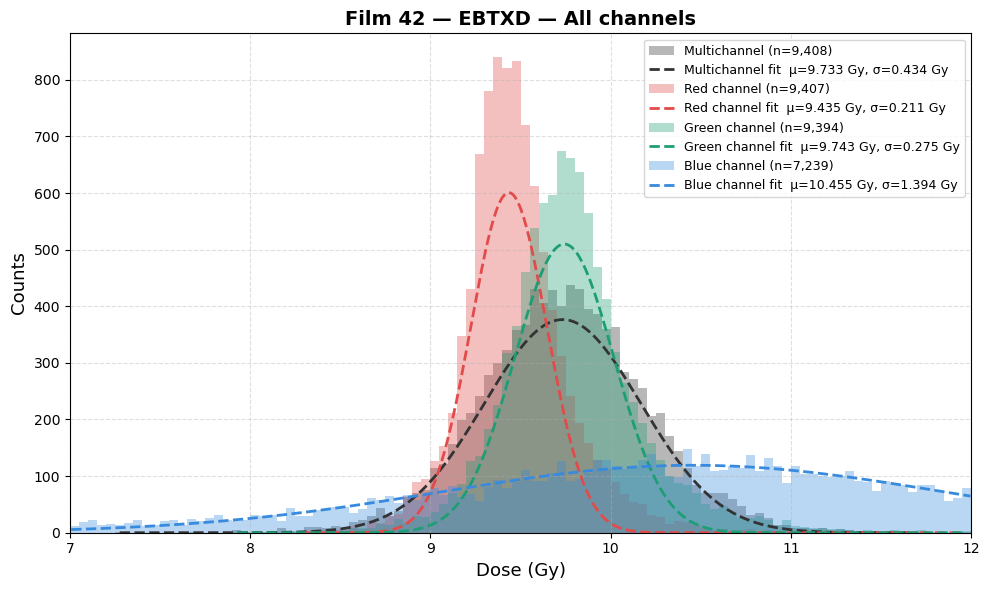

Processing dose_od_pair_51.csv  (film_type=EBTXD, channels=['multi', 'r', 'g', 'b'])
Saved → /home/michaelgajda/cal_Lab_Work/film_triple_channel_dosimetry/analyze_Dose_CSVs/hists/EBTXD_May15/dose_histogram_film_051_EBTXD_all.png


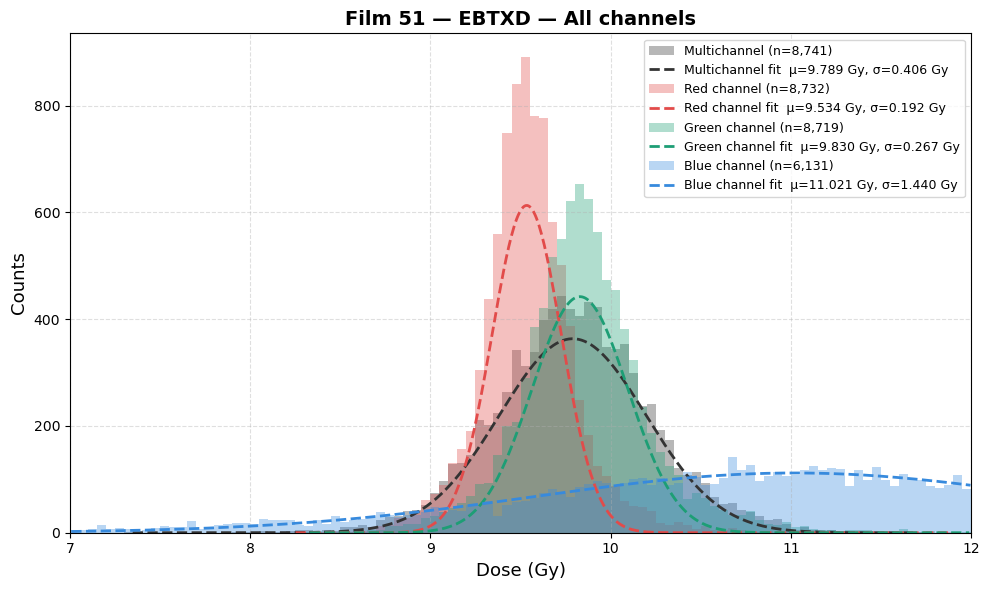

Processing dose_od_pair_62.csv  (film_type=EBTXD, channels=['multi', 'r', 'g', 'b'])
Saved → /home/michaelgajda/cal_Lab_Work/film_triple_channel_dosimetry/analyze_Dose_CSVs/hists/EBTXD_May15/dose_histogram_film_062_EBTXD_all.png


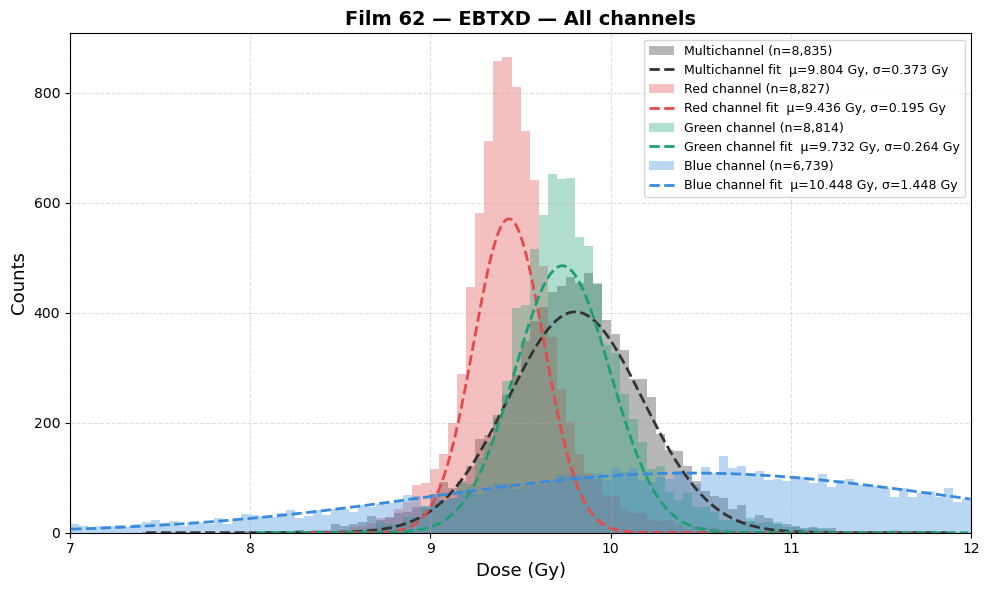

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
import re
from pathlib import Path


CHANNEL_CFG = {
    'D_multichannel': {'label': 'Multichannel',  'color': '#333333', 'alpha': 0.35},
    'D_r':            {'label': 'Red channel',   'color': '#E24B4A', 'alpha': 0.35},
    'D_g':            {'label': 'Green channel', 'color': '#1D9E75', 'alpha': 0.35},
    'D_b':            {'label': 'Blue channel',  'color': '#378ADD', 'alpha': 0.35},
}

CHANNEL_KEY_MAP = {
    'multi': 'D_multichannel',
    'r':     'D_r',
    'g':     'D_g',
    'b':     'D_b',
}

CHANNEL_NAMES = {
    'multi': 'Multichannel',
    'r':     'Red',
    'g':     'Green',
    'b':     'Blue',
}


def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def load_doses_from_csv(csv_path, channels=None):
    """
    Load dose columns from a single CSV file.

    Parameters
    ----------
    csv_path : str or Path
    channels : list of str or None — subset of ['multi','r','g','b'];
                                     loads all four if None
    """
    cols_to_load = (
        [CHANNEL_KEY_MAP[ch] for ch in channels]
        if channels else list(CHANNEL_CFG.keys())
    )

    data = {}
    df   = pd.read_csv(csv_path)

    for col in cols_to_load:
        if col in df.columns:
            vals      = df[col].dropna().values
            data[col] = vals[np.isfinite(vals)]
        else:
            print(f"Warning: column '{col}' not found in {Path(csv_path).name}")

    return data


def fit_gaussian(values, n_bins=100):
    """Fit a Gaussian to a histogram of values."""
    counts, bin_edges = np.histogram(values, bins=n_bins, density=False)
    bin_centres       = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    p0 = (counts.max(), values.mean(), values.std())

    try:
        params, _ = curve_fit(gaussian, bin_centres, counts, p0=p0, maxfev=5000)
        amp, mu, sigma = params
        sigma = abs(sigma)
    except RuntimeError:
        print("Warning: Gaussian fit did not converge, using mean/std estimates.")
        mu, sigma = values.mean(), values.std()
        amp       = counts.max()

    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
    y_fit = gaussian(x_fit, amp, mu, sigma)

    return x_fit, y_fit, mu, sigma


def extract_film_number(csv_path):
    """Extract trailing number from filename e.g. dose_od_pair_003.csv -> 3."""
    match = re.search(r'_(\d+)\.csv$', Path(csv_path).name)
    if match:
        return int(match.group(1))
    raise ValueError(f"Could not extract film number from filename: {csv_path}")


def channel_title_label(channels):
    """Build a readable string of selected channels for use in titles."""
    if channels is None or set(channels) == set(CHANNEL_KEY_MAP.keys()):
        return 'All channels'
    return ', '.join(CHANNEL_NAMES[ch] for ch in channels)


def channel_save_label(channels):
    """Build a compact string of selected channels for use in filenames."""
    if channels is None or set(channels) == set(CHANNEL_KEY_MAP.keys()):
        return 'all'
    return '_'.join(channels)


def plot_film_histogram(csv_path, film_type=None, channels=None,
                        n_bins=100, output_dir=None,
                        x_min=None, x_max=None):        # <-- add these
    """
    Parameters
    ----------
    x_min : float or None  — lower dose bound for display (Gy)
    x_max : float or None  — upper dose bound for display (Gy)
    """
    if channels is not None:
        invalid = [ch for ch in channels if ch not in CHANNEL_KEY_MAP]
        if invalid:
            raise ValueError(
                f"Invalid channel(s): {invalid}. "
                f"Choose from {list(CHANNEL_KEY_MAP.keys())}"
            )

    csv_path   = Path(csv_path)
    film_num   = extract_film_number(csv_path)
    type_label = f" — {film_type}"                     if film_type else ""
    ch_label   = f" — {channel_title_label(channels)}"
    title      = f"Film {film_num}{type_label}{ch_label}"
    save_name  = (
        f"dose_histogram_film_{film_num:03d}"
        f"{'_' + film_type if film_type else ''}"
        f"_{channel_save_label(channels)}.png"
    )

    data = load_doses_from_csv(csv_path, channels)

    fig, ax = plt.subplots(figsize=(10, 6))

    cols_to_plot = (
        [CHANNEL_KEY_MAP[ch] for ch in channels]
        if channels else list(CHANNEL_CFG.keys())
    )

    for col in cols_to_plot:
        if col not in data:
            continue

        cfg    = CHANNEL_CFG[col]
        values = data[col]

        # clip to requested range before histogramming and fitting
        if x_min is not None:
            values = values[values >= x_min]
        if x_max is not None:
            values = values[values <= x_max]

        if len(values) == 0:
            print(f"Warning: no data in range [{x_min}, {x_max}] "
                  f"for channel {col}")
            continue

        ax.hist(
            values,
            bins=n_bins,
            range=(x_min if x_min is not None else values.min(),
                   x_max if x_max is not None else values.max()),
            color=cfg['color'],
            alpha=cfg['alpha'],
            label=f"{cfg['label']} (n={len(values):,})",
            density=False,
        )

        x_fit, y_fit, mu, sigma = fit_gaussian(values, n_bins=n_bins)

        ax.plot(
            x_fit, y_fit,
            color=cfg['color'],
            linewidth=2.0,
            linestyle='--',
            label=f"{cfg['label']} fit  μ={mu:.3f} Gy, σ={sigma:.3f} Gy",
        )

    # set axis limits if specified
    if x_min is not None or x_max is not None:
        ax.set_xlim(left=x_min, right=x_max)

    ax.set_xlabel('Dose (Gy)', fontsize=13)
    ax.set_ylabel('Counts',    fontsize=13)
    ax.set_title(title,        fontsize=14, fontweight='bold')
    ax.legend(fontsize=9,      loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()

    if output_dir:
        # make a subdirectory named after the parent folder of the CSVs
        csv_parent_name = csv_path.parent.name
        save_dir = Path(output_dir) / csv_parent_name
        os.makedirs(save_dir, exist_ok=True)
        out_path = save_dir / save_name
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {out_path}")

    plt.show()
    plt.close()


def plot_all_film_histograms(csv_dir, film_types=None, channels=None,
                             n_bins=100, output_dir=None,
                             x_min=None, x_max=None):        # <-- add these
    csv_files = sorted(
        Path(csv_dir).glob('*.csv'),
        key=lambda f: extract_film_number(f)
    )

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {csv_dir}")

    if film_types is not None and len(film_types) != len(csv_files):
        raise ValueError(
            f"film_types has {len(film_types)} entries but found "
            f"{len(csv_files)} CSV files."
        )

    for idx, csv_path in enumerate(csv_files):
        film_type = film_types[idx] if film_types is not None else None
        print(f"Processing {csv_path.name}  "
              f"(film_type={film_type}, channels={channels})")
        plot_film_histogram(
            csv_path=csv_path,
            film_type=film_type,
            channels=channels,
            n_bins=n_bins,
            output_dir=output_dir,
            x_min=x_min,            # <-- pass through
            x_max=x_max,
        )
        


if __name__ == "__main__":
    film_types = ['EBTXD' for _ in range(7)]

    plot_all_film_histograms(
        csv_dir='/home/michaelgajda/cal_Lab_Work/film_triple_channel_dosimetry/analyze_Dose_CSVs/EBTXD_May15',
        film_types=film_types,
        channels=['multi', 'r', 'g', 'b'],
        n_bins=100,
        output_dir='/home/michaelgajda/cal_Lab_Work/film_triple_channel_dosimetry/analyze_Dose_CSVs/hists',
        x_min=7,     # only show doses between 0 and 10 Gy
        x_max=12.0,
    )